# Fake, Real and AI-Generated News Detection
## [CM3070] Final Project, NLP Fake News Detection Template

## 1. Data
Let's start with importing the data.

In [250]:
import pandas as pd
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt #Plotting properties
import seaborn as sns
# Set style for seaborn for better readability
sns.set(style="whitegrid")
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For WordNet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Show all matplotlib graphs inline
%matplotlib inline

[nltk_data] Downloading package stopwords to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [252]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: celery 5.0.5 has a non-standard dependency specifier pytz>dev. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of celery or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [254]:
from wordcloud import WordCloud

### Download AI-generated GPT-2 Data

In [4]:
import os
import sys
import requests
from tqdm import tqdm
import re

[nltk_data] Downloading package stopwords to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\hp 840
[nltk_data]     G6\AppData\Roaming\nltk_data...


In [5]:
# subdir = 'data'
# if not os.path.exists(subdir):
#     os.makedirs(subdir)
# subdir = subdir.replace('\\','/') # needed for Windows


# # Just downloading outputs from strongest version (xl-1542M)

# # The dataset contains train, valid and test sets, but the number of samples
# # is so large that we only need the training set (250,000 samples)
# filename = 'xl-1542M-k40.train.jsonl'
# r = requests.get("https://openaipublic.azureedge.net/gpt-2/output-dataset/v1/" + filename, stream=True)

# with open(os.path.join(subdir, filename), 'wb') as f:
#     file_size = int(r.headers["content-length"])
#     chunk_size = 1000
#     with tqdm(ncols=100, desc="Fetching " + filename, total=file_size, unit_scale=True) as pbar:
#         # 1k for chunk_size, since Ethernet packet size is around 1500 bytes
#         for chunk in r.iter_content(chunk_size=chunk_size):
#             f.write(chunk)
#             pbar.update(chunk_size)

In [6]:
# ai_df = pd.read_json('data/xl-1542M-k40.train.jsonl', lines=True)

In [7]:
# ai_df.to_csv('data/gpt2_output.csv', index=False)

In [8]:
gpt2_df = pd.read_csv('data/gpt2_output.csv')

In [9]:
# Confirm length is correct (250,000 expected)
print("Number of AI text articles: " + str(len(gpt2_df)))

Number of AI text articles: 250000


In [10]:
gpt2_df.head()

,id,text,length,ended
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True
1,2,The latest edition of the German Football Hall...,715,True
2,3,"Dangerous animals, especially snakes, in a car...",1024,False
3,4,I started my first MLP story way back in 2014 ...,1024,False
4,5,This article is a disambiguation page for The ...,84,True


In [11]:
# Printing first output
gpt2_df.iloc[0, 1]

'Cops will have to take "extreme care" to avoid jail-breaking the latest iPhones as the US government will fine manufacturers for breaking its digital security.\n\nApple has been criticised for designing and releasing its latest smartphone without any security measures.\n\nApple has defended the iPhone 6 for carrying out some of its advanced security measures, but will be fined if it continues to fail that test.\n\nThe Federal Communications Commission and FBI will be allowed to fine companies as much as $25,000 (£17,800) for not patching bugs after they are announced.\n\nThe FCC, under a new ruling from president Obama , will allow fines of $1,500 per device over the same "bug bounty".\n\nThere have been multiple hacks into iPhone 6 smartphones this year in the wake of the 2013 revelation that the device could be unlocked with a passcode lock.\n\nHowever, security experts have criticised Apple\'s software and device for not patching its bugs to prevent them becoming the latest weapon 

### Download Fake and Real News Data

In [13]:
# Load Kaggle Dataset (Real vs. Fake News)
real_news = pd.read_csv('data/True.csv')
fake_news = pd.read_csv('data/Fake.csv')

In [14]:
real_news.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [15]:
fake_news.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


### Dowload LIAR Dataset

In [17]:
# Load LIAR dataset
# Import the LIAR dataset without headers
columns = ["id", "label", "statement", "subject", "speaker", "job_title", "state", 
           "party", "barely_true_count", "false_count", "half_true_count", 
           "mostly_true_count", "pants_fire_count", "context"]

liar_train = pd.read_csv("data/train.tsv", sep='\t', header=None, names=columns)  # LIAR is tab-separated
liar_test = pd.read_csv("data/test.tsv", sep='\t', header=None, names=columns)
liar_valid = pd.read_csv("data/valid.tsv", sep='\t', header=None, names=columns)

In [18]:
liar_train.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [19]:
liar_test.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [20]:
liar_valid.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


### Data Pre-processing and Cleaning
After all the datasets have been imported, we will go into pre-processing them.

#### Pre-processing the fake and real news Kaggle dataset

In [23]:
# combining true and fake dataframes and adding a column for labels
fake_news['label'] = 'fake'
real_news['label'] = 'real'
news_df = pd.concat([fake_news, real_news], ignore_index=True)

In [24]:
news_df = news_df.drop_duplicates(subset='text').reset_index(drop=True)

In [25]:
news_df = news_df.dropna(subset=['text'])

In [26]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters and numbers, keep only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = text.split()
    # Remove stopwords and lemmatize each word
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Rejoin the words into a single string
    return " ".join(words)

In [27]:
news_df['cleaned_text'] = news_df['text'].apply(clean_text)

In [28]:
news_df.head()

,title,text,subject,date,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake,pope francis used annual christmas day message...


In [29]:
news_df.tail()

,title,text,subject,date,label,cleaned_text
38641,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",real,brussels reuters nato ally tuesday welcomed pr...
38642,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",real,london reuters lexisnexis provider legal regul...
38643,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",real,minsk reuters shadow disused sovietera factory...
38644,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",real,moscow reuters vatican secretary state cardina...
38645,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",real,jakarta reuters indonesia buy sukhoi fighter j...


In [30]:
news_df.drop(['date', 'text', 'subject'], axis=1, inplace=True)

In [31]:
news_df.head()

,title,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,fake,pope francis used annual christmas day message...


In [32]:
news_df = news_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [33]:
news_df.drop(['title'], axis=1, inplace=True)

In [34]:
news_df = news_df[["text", "label"]]

In [35]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


#### Pre-processing the LIAR dataset

In [37]:
# Drop unnecessary columns
columns_to_keep = ["label", "statement"]
liar_train = liar_train[columns_to_keep]
liar_test = liar_test[columns_to_keep]
liar_valid = liar_valid[columns_to_keep]

In [38]:
liar_valid.head()

,label,statement
0,barely-true,We have less Americans working now than in the...
1,pants-fire,"When Obama was sworn into office, he DID NOT u..."
2,false,Says Having organizations parading as being so...
3,half-true,Says nearly half of Oregons children are poor.
4,half-true,On attacks by Republicans that various program...


In [39]:
liar_test.head()

,label,statement
0,true,Building a wall on the U.S.-Mexico border will...
1,false,Wisconsin is on pace to double the number of l...
2,false,Says John McCain has done nothing to help the ...
3,half-true,Suzanne Bonamici supports a plan that will cut...
4,pants-fire,When asked by a reporter whether hes at the ce...


In [40]:
liar_train.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [41]:
liar_df = pd.concat([liar_train, liar_test, liar_valid], ignore_index=True)

In [42]:
liar_df.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [43]:
liar_df.tail()

,label,statement
12786,half-true,"For the first time in more than a decade, impo..."
12787,mostly-true,Says Donald Trump has bankrupted his companies...
12788,true,"John McCain and George Bush have ""absolutely n..."
12789,false,A new poll shows 62 percent support the presid...
12790,barely-true,No one claims the report vindicating New Jerse...


In [44]:
# Shuffle the data to ensure randomness
liar_df = liar_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [45]:
# Save the combined LIAR dataset
liar_df.to_csv("liar.csv", index=False)

In [46]:
def simplify_label(label):
    if label in ['false', 'pants-fire', 'barely-true']:
        return 'fake'
    else:
        return 'real'

liar_df['label'] = liar_df['label'].apply(simplify_label)

In [47]:
liar_df.head()

,label,statement
0,fake,"In the event of a U.S. strike on Syria, the Ru..."
1,real,To give the proposed economic stimulus plan so...
2,fake,Its warmer on Mars than it is in parts of the ...
3,real,The health insurance plan that (members of Con...
4,fake,He's promising four more years of an administr...


In [48]:
liar_df.describe()

,label,statement
count,12791,12791
unique,2,12765
top,real,On changing the rules for filibusters on presi...
freq,7134,3


In [49]:
liar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      12791 non-null  object
 1   statement  12791 non-null  object
dtypes: object(2)
memory usage: 200.0+ KB


In [50]:
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

In [51]:
liar_df = liar_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [52]:
liar_df.drop(['statement'], axis=1, inplace=True)

In [53]:
liar_df = liar_df[["text", "label"]]

In [54]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


#### Pre-processing the GPT2-output Dataset

In [56]:
gpt2_df["label"] = "AI-generated"

In [57]:
gpt2_df.head()

,id,text,length,ended,label
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True,AI-generated
1,2,The latest edition of the German Football Hall...,715,True,AI-generated
2,3,"Dangerous animals, especially snakes, in a car...",1024,False,AI-generated
3,4,I started my first MLP story way back in 2014 ...,1024,False,AI-generated
4,5,This article is a disambiguation page for The ...,84,True,AI-generated


In [58]:
gpt2_df.drop(['id', 'length', 'ended'], axis=1, inplace=True)

In [59]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [60]:
# Remove duplicates and handle missing values
gpt2_df.drop_duplicates(subset="text", inplace=True)
gpt2_df.dropna(subset=["text"], inplace=True)

In [61]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [62]:
gpt2_df['text'] = gpt2_df['text'].apply(clean_text)

In [63]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


### Checking All the Datasets

In [65]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


In [66]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


In [67]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


In [68]:
news_df.tail()

,text,label
38641,brussels reuters nato ally tuesday welcomed pr...,real
38642,london reuters lexisnexis provider legal regul...,real
38643,minsk reuters shadow disused sovietera factory...,real
38644,moscow reuters vatican secretary state cardina...,real
38645,jakarta reuters indonesia buy sukhoi fighter j...,real


In [69]:
liar_df.tail()

,text,label
12786,say opponent health care law prevailed two mai...,real
12787,mosque near ground zero,real
12788,louie gohmert texas blamed mass shooting movie...,fake
12789,governor consult member party released transpo...,fake
12790,telecom bill could keep state corporation comm...,fake


In [70]:
gpt2_df.tail()

,text,label
249995,lot thing dont like job cooped office long hou...,AI-generated
249996,year unprecedented public outcry use water pun...,AI-generated
249997,battle english scot english victory flodden ki...,AI-generated
249998,kurt rambis new head coach knicks kurt rambis ...,AI-generated
249999,leader need thats differ new president united ...,AI-generated


In [71]:
# saving all cleaned dataframes to CSV files.
news_df.to_csv('data/news.csv', index=False)
liar_df.to_csv('data/liar.csv', index=False)
gpt2_df.to_csv('data/gpt2.csv', index=False)

In [72]:
news_df["label"].value_counts()

label
real    21191
fake    17455
Name: count, dtype: int64

In [73]:
liar_df["label"].value_counts()

label
real    7134
fake    5657
Name: count, dtype: int64

In [74]:
gpt2_df["label"].value_counts()

label
AI-generated    249796
Name: count, dtype: int64

## Downsampling the GPT-2-output Dataset
The GPT-2 output dataset is about 250000 values which need to be downsamlped to avoid data imbalance and model bias.

In [76]:
gpt2_sampled = gpt2_df.sample(n=23000, random_state=42)

### Downsampling the real samples in LIAR and kaggle Datasets
This reduces bias from the overrepresented real class while preserving the diversity of text samples, because real has significantly more samples than fake in news_df and liar_df.

In [78]:
# Downsample real class in news_df
real_downsampled = news_df[news_df['label'] == 'real'].sample(n=17455, random_state=42)
fake = news_df[news_df['label'] == 'fake']
balanced_news_df = pd.concat([real_downsampled, fake])

# Downsample real class in news_df
liar_real_downsampled = liar_df[liar_df['label'] == 'real'].sample(n=5657, random_state=42)
liar_fake = liar_df[liar_df['label'] == 'fake']
balanced_liar_df = pd.concat([liar_real_downsampled, liar_fake])

## Merging the Datasets
After balancing, I will combine gpt2_df, balanced_news_df, and balanced_liar_df.

In [80]:
# Rename labels for consistency
gpt2_sampled['label'] = 'AI-generated'
balanced_news_df['label'] = balanced_news_df['label'].map({'real': 'real', 'fake': 'fake'})
balanced_liar_df['label'] = balanced_liar_df['label'].map({'real': 'real', 'fake': 'fake'})

# Merge datasets
merged_df = pd.concat([balanced_news_df, balanced_liar_df, gpt2_sampled])

In [81]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

### Shuffling the dataset to mix samples from different sources.

In [83]:
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [84]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

In [85]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [86]:
merged_df.shape

(69224, 2)

In [87]:
merged_df.isnull().sum()

text     0
label    0
dtype: int64

## Exploratory Data Analysis

In [197]:
# Get basic info (data types, non-null counts)
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB
None


In [199]:
# Get statistical summary for numerical columns
print(merged_df.describe())

         text  label
count   69224  69224
unique  69035      3
top             real
freq       63  23112


In [201]:
# Check for null values
print(merged_df.isnull().sum())

text     0
label    0
dtype: int64


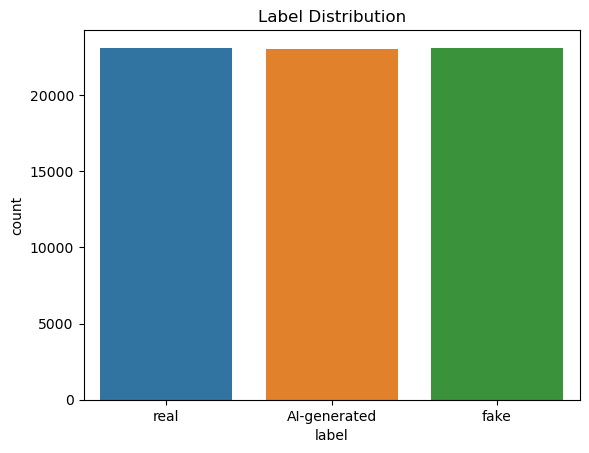

In [203]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
sns.countplot(data=merged_df, x='label')
plt.title('Label Distribution')
plt.show()

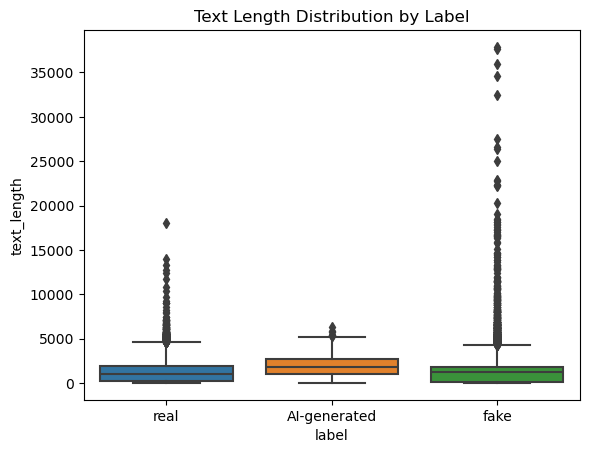

In [207]:
# Plot text length vs label
sns.boxplot(data=merged_df, x='label', y='text_length')
plt.title('Text Length Distribution by Label')
plt.show()

In [209]:
# Check for duplicates in text and label columns
duplicates = merged_df.duplicated(subset=['text', 'label'])
print(f"Number of duplicate entries: {duplicates.sum()}")

Number of duplicate entries: 184


In [211]:
merged_df = merged_df.drop_duplicates(subset=['text', 'label'], keep='first')

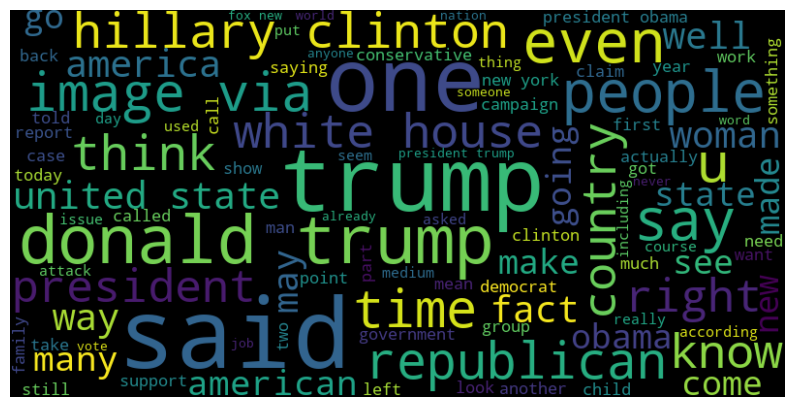

In [256]:
from wordcloud import WordCloud

wordcloud_text = ''.join(merged_df[merged_df['label']=='fake']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

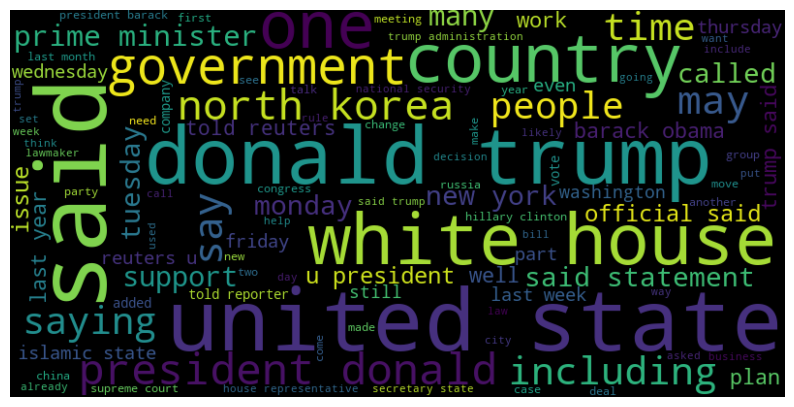

In [258]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='real']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

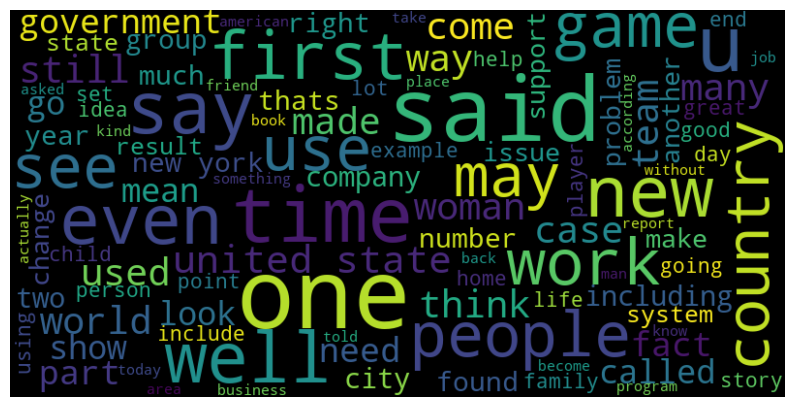

In [261]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='AI-generated']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Data Splitting
Spliting the dataset into training, validation, and testing sets:
- Training Set: 64% of the data
- Validation Set: 16% of the data
- Testing Set: 20% of the data

In [213]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% testing.
train_df, test_df = train_test_split(merged_df, test_size=0.2, stratify=merged_df['label'], random_state=42)
# Then taking 20% of the 80% training data (16% of the original dataset) for validation.
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

## Baseline Modeling
### Vectorization with TF-IDF

In [232]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [218]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=10_000)
X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

If the labels are text strings ("fake", "real", "AI-generated"), they need to be encoded numerically for sklearn models. LabelEncoder or OneHotEncoder can be used.

In [220]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

### Logistic Regression

In [222]:
# Model Training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [224]:
# Validation Predictions
y_pred = model.predict(X_val)

In [234]:
# Print Accuracy Score
print(accuracy_score(y_val, y_pred))

0.8693763012582602


In [226]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.93      0.91      0.92      3678
        fake       0.84      0.84      0.84      3685
        real       0.85      0.86      0.86      3684

    accuracy                           0.87     11047
   macro avg       0.87      0.87      0.87     11047
weighted avg       0.87      0.87      0.87     11047



In [228]:
# Test Predictions
y_test_pred = model.predict(X_test)
print("Test Metrics:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Test Metrics:
              precision    recall  f1-score   support

AI-generated       0.92      0.91      0.92      4597
        fake       0.85      0.85      0.85      4606
        real       0.86      0.87      0.86      4605

    accuracy                           0.88     13808
   macro avg       0.88      0.88      0.88     13808
weighted avg       0.88      0.88      0.88     13808



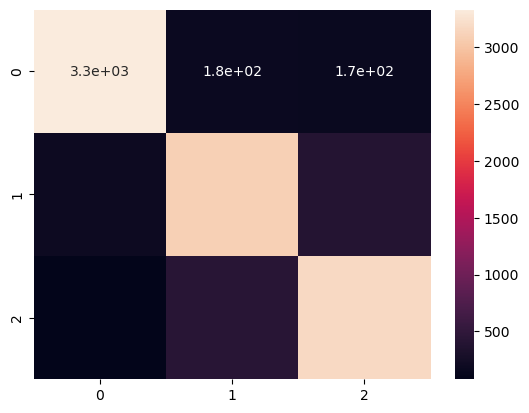

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt #Plotting properties
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True)
plt.show()